# 02 · What Indonesia grows

Top crops by production, area harvested, and value — and how the mix has shifted over time.

## Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, matplotlib.pyplot as plt
from src.load import load_indonesia
from src.clean import drop_item_aggregates
from src import viz

qcl = load_indonesia('QCL')
qv  = load_indonesia('QV')
LATEST = qcl['year'].max()
print('latest year:', LATEST)

[cache] QCL_indonesia_2010_2024.parquet


[cache] QV_indonesia_2010_2024.parquet
latest year: 2024


## Top crops by production (latest year)

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_top_crops_by_production.png


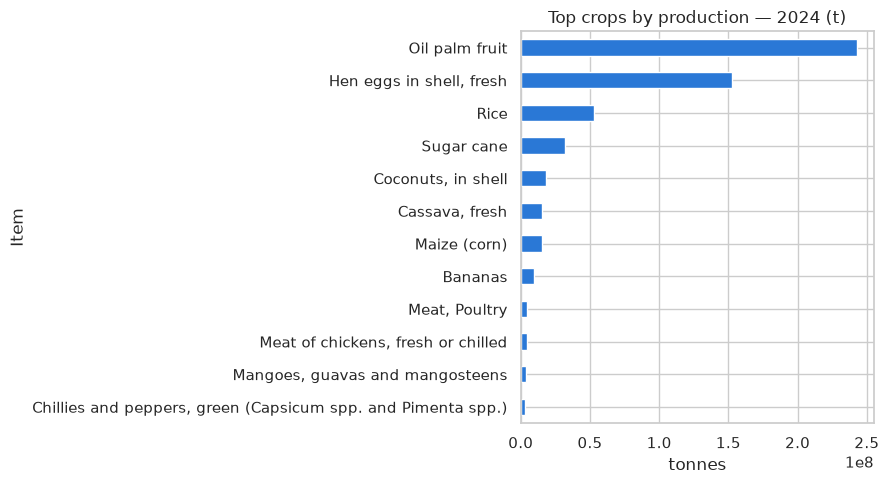

Item
Oil palm fruit                                                  2.430000e+08
Hen eggs in shell, fresh                                        1.527872e+08
Rice                                                            5.314273e+07
Sugar cane                                                      3.200000e+07
Coconuts, in shell                                              1.798539e+07
Cassava, fresh                                                  1.562404e+07
Maize (corn)                                                    1.513891e+07
Bananas                                                         9.260387e+06
Meat, Poultry                                                   4.217701e+06
Meat of chickens, fresh or chilled                              4.179444e+06
Mangoes, guavas and mangosteens                                 4.136617e+06
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)    3.038082e+06
Name: value, dtype: float64

In [2]:
prod = qcl[(qcl['Element'] == 'Production') & (qcl['year'] == LATEST)]
prod = drop_item_aggregates(prod)
top_prod = prod.groupby('Item')['value'].sum().sort_values(ascending=False)
fig, ax = viz.barh_ranking(top_prod, f'Top crops by production — {LATEST} (t)', 'tonnes', n=12)
viz.save(fig, 'idn_top_crops_by_production')
plt.show()
top_prod.head(12)

## Top crops by area harvested (latest year)
Volume isn't the same as footprint on land — worth comparing.

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_top_crops_by_area_harvested.png


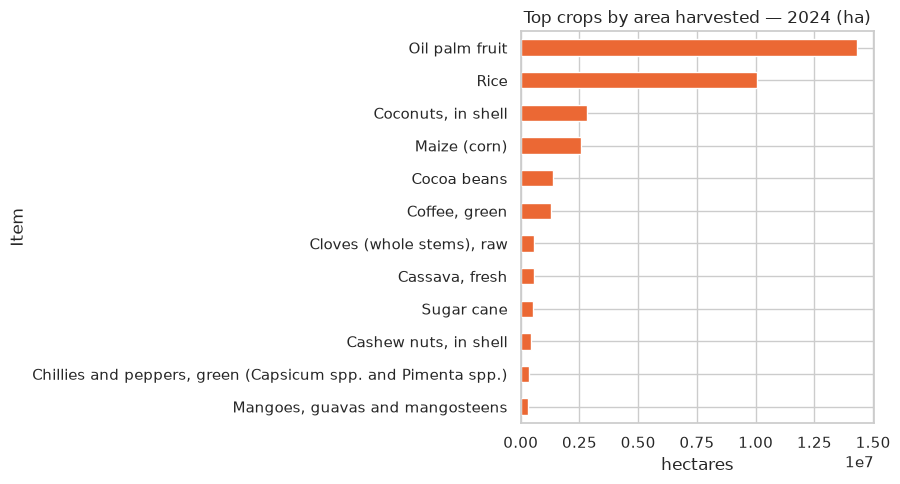

Item
Oil palm fruit                                                  14320000.0
Rice                                                            10046135.0
Coconuts, in shell                                               2820000.0
Maize (corn)                                                     2548654.0
Cocoa beans                                                      1386749.0
Coffee, green                                                    1269354.0
Cloves (whole stems), raw                                         576195.0
Cassava, fresh                                                    553450.0
Sugar cane                                                        524886.0
Cashew nuts, in shell                                             439322.0
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)      330218.0
Mangoes, guavas and mangosteens                                   289744.0
Name: value, dtype: float64

In [3]:
area = qcl[(qcl['Element'] == 'Area harvested') & (qcl['year'] == LATEST)]
area = drop_item_aggregates(area)
top_area = area.groupby('Item')['value'].sum().sort_values(ascending=False)
fig, ax = viz.barh_ranking(top_area, f'Top crops by area harvested — {LATEST} (ha)', 'hectares', n=12, color='#eb6834')
viz.save(fig, 'idn_top_crops_by_area_harvested')
plt.show()
top_area.head(12)

## Top crops by value (latest year with QV coverage)

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_top_crops_by_value.png


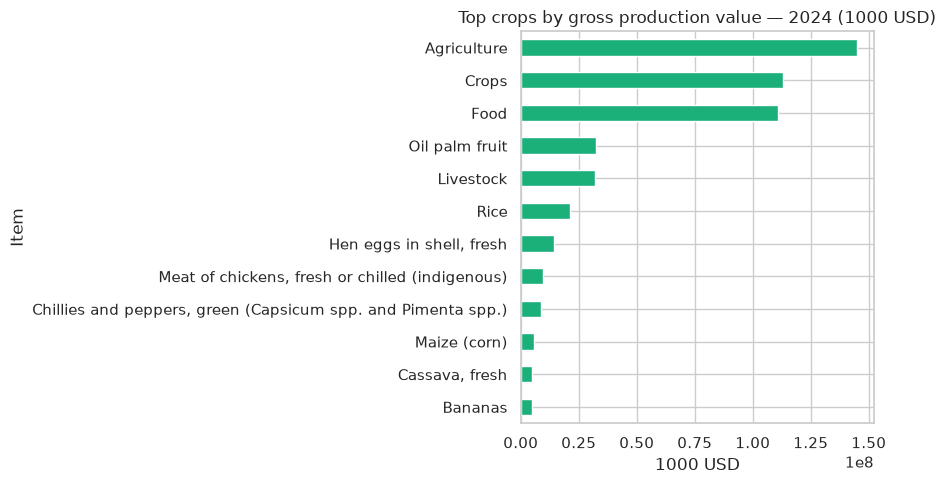

Item
Agriculture                                                     144990531.0
Crops                                                           113087285.0
Food                                                            110803674.0
Oil palm fruit                                                   32258172.0
Livestock                                                        31903246.0
Rice                                                             21311766.0
Hen eggs in shell, fresh                                         14127281.0
Meat of chickens, fresh or chilled (indigenous)                   9692873.0
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)      8756181.0
Maize (corn)                                                      5642307.0
Cassava, fresh                                                    4755081.0
Bananas                                                           4647615.0
Name: value, dtype: float64

In [4]:
qv_latest = qv['year'].max()
val = qv[(qv['Element'] == 'Gross Production Value (current thousand US$)')
        & (qv['year'] == qv_latest)]
val = drop_item_aggregates(val)
top_val = val.groupby('Item')['value'].sum().sort_values(ascending=False)
fig, ax = viz.barh_ranking(top_val, f'Top crops by gross production value — {qv_latest} (1000 USD)', '1000 USD', n=12, color='#1baf7a')
viz.save(fig, 'idn_top_crops_by_value')
plt.show()
top_val.head(12)

## Crop mix over time — the big 5 by production

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_production_trend_top5.png


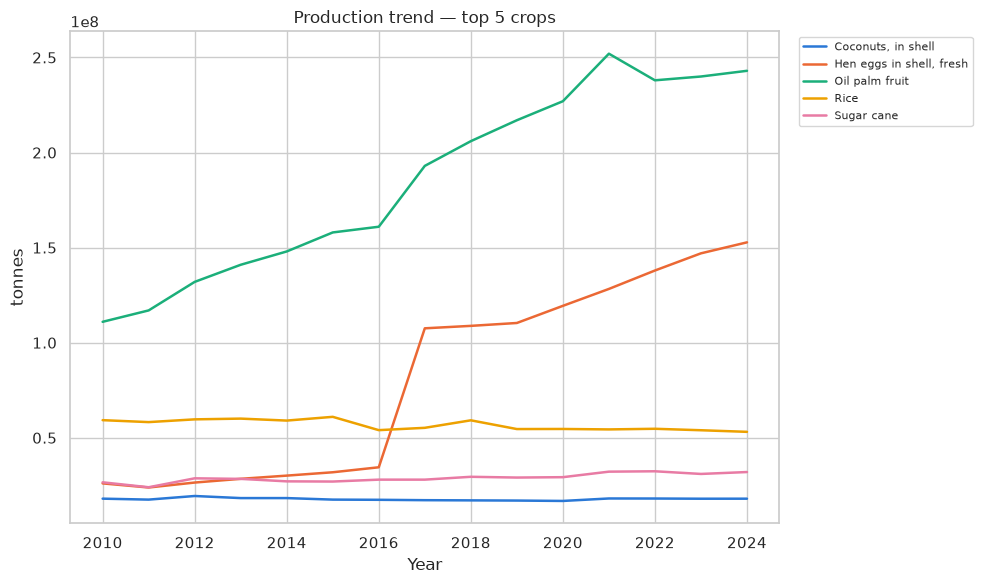

In [5]:
focus = list(top_prod.head(5).index)
trend = qcl[(qcl['Element'] == 'Production') & (qcl['Item'].isin(focus))]
fig, ax = viz.trend_over_time(trend, 'year', 'value', group_col='Item',
                              title='Production trend — top 5 crops', ylabel='tonnes')
viz.save(fig, 'idn_production_trend_top5')
plt.show()

## Yield trend for the staple (rice)
Is growth coming from more land, or more yield per hectare?

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_rice_area_vs_yield.png


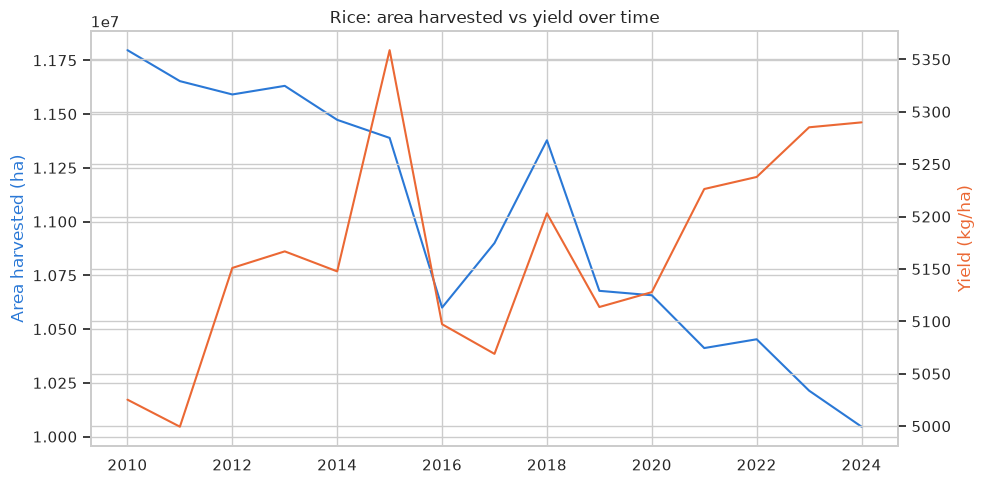

In [6]:
rice = qcl[(qcl['Item'] == 'Rice') & (qcl['Element'].isin(['Production', 'Area harvested', 'Yield']))]
piv = rice.pivot_table(index='year', columns='Element', values='value')
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.plot(piv.index, piv['Area harvested'], color='#2a78d6', label='Area harvested (ha)')
ax2.plot(piv.index, piv['Yield'], color='#eb6834', label='Yield')
ax.set_ylabel('Area harvested (ha)', color='#2a78d6')
ax2.set_ylabel(f"Yield ({rice[rice['Element']=='Yield']['Unit'].iloc[0]})", color='#eb6834')
ax.set_title('Rice: area harvested vs yield over time')
fig.tight_layout()
viz.save(fig, 'idn_rice_area_vs_yield')
plt.show()

## Summary

Fill in after running:
- **Biggest crop by volume:** … (likely oil palm fruit)
- **Biggest crop by value:** …
- **Staple (rice) growth driver:** area expansion vs yield gains — …
- Next: `03_when_it_grows` — seasonality / cropping calendar.